# Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd

# Load the data
data = pd.read_csv('/Users/apple/Downloads/Kaggle Data Science Survey 2017-2021/kaggle_survey_2017_2021.csv', low_memory=False)

print(data.head)

# Check for missing values
print(data.isnull().sum())

<bound method NDFrame.head of            - Time from Start to Finish (seconds)                           Q1  \
0       Year               Duration (in seconds)  What is your age (# years)?   
1       2021                                 910                        50-54   
2       2021                                 784                        50-54   
3       2021                                 924                        22-24   
4       2021                                 575                        45-49   
...      ...                                 ...                          ...   
106297  2017                                 NaN                        22-24   
106298  2017                                 NaN                        25-29   
106299  2017                                 NaN                        25-29   
106300  2017                                 NaN                          NaN   
106301  2017                                 NaN                        25-29  

In [2]:
import pandas as pd
import re
from sklearn.preprocessing import LabelEncoder

# 1. Load data and remove the question header row
df = data.drop(0).reset_index(drop=True)

# 2. The Cleaning Function
def clean_survey_text(text):
    if pd.isna(text) or text == 'Unknown':
        return "no answer"
    
    # This keeps only alphanumeric characters and spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', '', str(text))
    
    # Convert to lowercase and remove extra whitespace
    text = " ".join(text.split()).lower().strip()
    return text

# 3. Apply cleaning
df['Q4_Clean'] = df['Q4'].apply(clean_survey_text)
df['Q5_Clean'] = df['Q5'].apply(clean_survey_text)

# 4. LABEL ENCODING
le = LabelEncoder()
df['Job_Title_Encoded'] = le.fit_transform(df['Q5_Clean'])

In [3]:
# Clean up the Q1 column to ensure consistency
df['Q1'] = df['Q1'].astype(str).replace(['nan', 'No Answer', 'Unknown'], None)

# 2. Find the Mode
age_mode = df['Q1'].mode()[0]

# 3. Fill the missing values (None) with the Mode
df['Q1_Imputed'] = df['Q1'].fillna(age_mode)

In [4]:
edu_mapping = {
    "Bachelor’s degree": 1,
    "Master’s degree": 2,
    "Doctoral degree": 3
}
df['Education_Score'] = df['Q4_Clean'].map(edu_mapping)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Job_Title_Encoded'] = le.fit_transform(df['Q5_Clean'].astype(str))

In [5]:
# 1. Top 5 Programming Languages
languages = [col for col in df.columns if 'Q7' in col]
top_langs = df[languages].count().sort_values(ascending=False).head(5)

# 2. Most Common Job Titles
top_jobs = df['Q5_Clean'].value_counts().head(5)

# 3. Education Level Distribution
top_edu = df['Q4_Clean'].value_counts().head(5)

# 4. Experience vs. Role (Grouping)
exp_role = df.groupby('Q6')['Q5_Clean'].value_counts().unstack().fillna(0)

# 5. Salary Distribution (Example using Q25)
top_salaries = df['Q25'].value_counts().head(5)

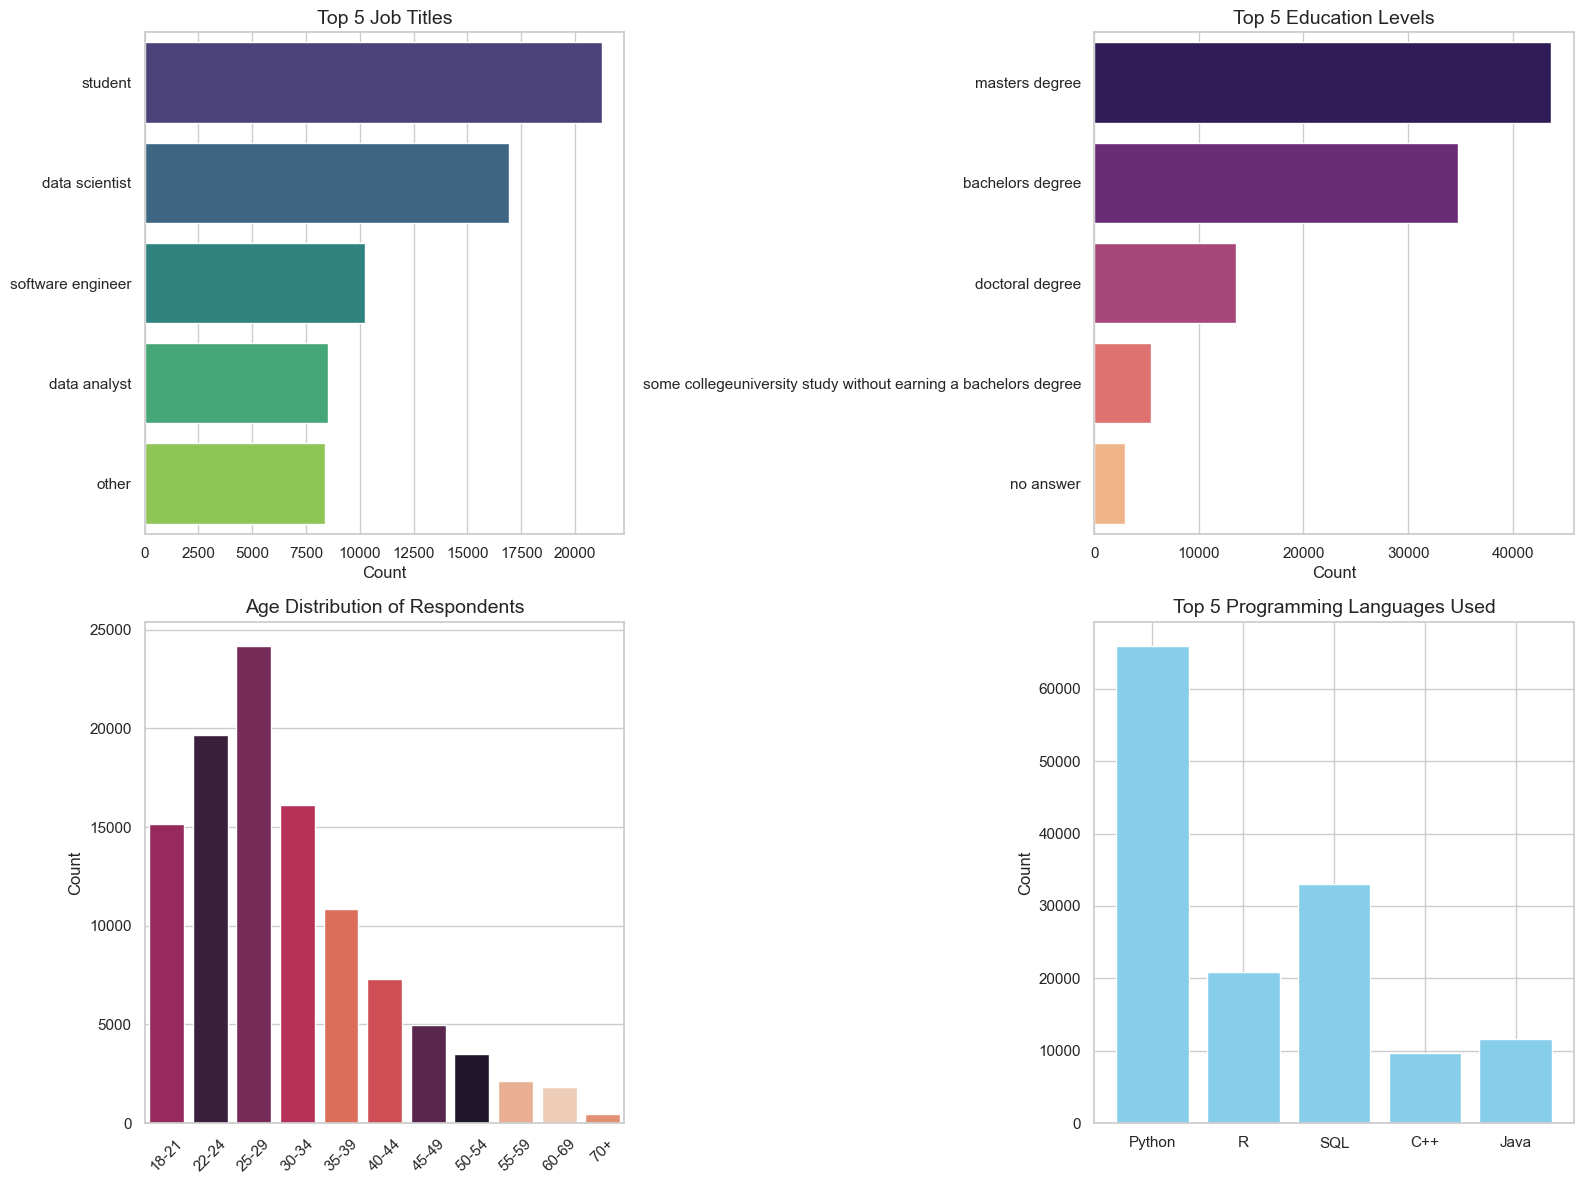

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

# --- Insight 1: Top 5 Job Titles ---
plt.subplot(2, 2, 1)
top_jobs = df['Q5_Clean'].value_counts().head(5)
sns.barplot(x=top_jobs.values, y=top_jobs.index, hue=top_jobs.index, palette='viridis', legend=False)
plt.title('Top 5 Job Titles', fontsize=14)
plt.ylabel('')
plt.xlabel('Count')

# --- Insight 2: Top 5 Education Levels ---
plt.subplot(2, 2, 2)
top_edu = df['Q4_Clean'].value_counts().head(5)
sns.barplot(x=top_edu.values, y=top_edu.index, hue=top_edu.index, palette='magma', legend=False)
plt.title('Top 5 Education Levels', fontsize=14)
plt.ylabel('')
plt.xlabel('Count')

# --- Insight 3: Age Distribution ---
plt.subplot(2, 2, 3)
# Filtering to ensure clean display
age_data = df['Q1_Imputed'].astype(str)
sns.countplot(x=age_data, order=sorted(age_data.unique()), hue=age_data, palette='rocket', legend=False)
plt.xticks(rotation=45)
plt.title('Age Distribution of Respondents', fontsize=14)
plt.ylabel('Count')
plt.xlabel('')

# --- Insight 4: Top 5 Programming Languages ---
plt.subplot(2, 2, 4)
languages = {
    'Python': df['Q7_Part_1'].replace('No Answer', np.nan).notna().sum(),
    'R': df['Q7_Part_2'].replace('No Answer', np.nan).notna().sum(),
    'SQL': df['Q7_Part_3'].replace('No Answer', np.nan).notna().sum(),
    'C++': df['Q7_Part_4'].replace('No Answer', np.nan).notna().sum(),
    'Java': df['Q7_Part_5'].replace('No Answer', np.nan).notna().sum()
}
plt.bar(languages.keys(), languages.values(), color='skyblue')
plt.title('Top 5 Programming Languages Used', fontsize=14)
plt.ylabel('Count')

plt.tight_layout()
plt.show()